In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.stats import gaussian_kde

np.random.seed(42)
n = 3000

# Параметры c = p/n
c_values = [0.3, 0.5, 1.0, 2.0]
num_bins = 25

In [2]:
def mp_pdf(x, c):
    """Плотность распределения Марченко-Пастура"""
    # Границы спектра
    a = (1 - np.sqrt(c))**2
    b = (1 + np.sqrt(c))**2
    
    condition = (x >= a) & (x <= b)
    
    result = np.zeros_like(x)
    result[condition] = (np.sqrt((b - x[condition]) * (x[condition] - a)) 
                         / (2 * np.pi * c * x[condition]))
    return result

In [3]:
def generate_covariance_matrix(p, n):
    """Генерация выборочной ковариационной матрицы"""
    X = np.random.randn(p, n)
    S = X @ X.T / n
    
    return S

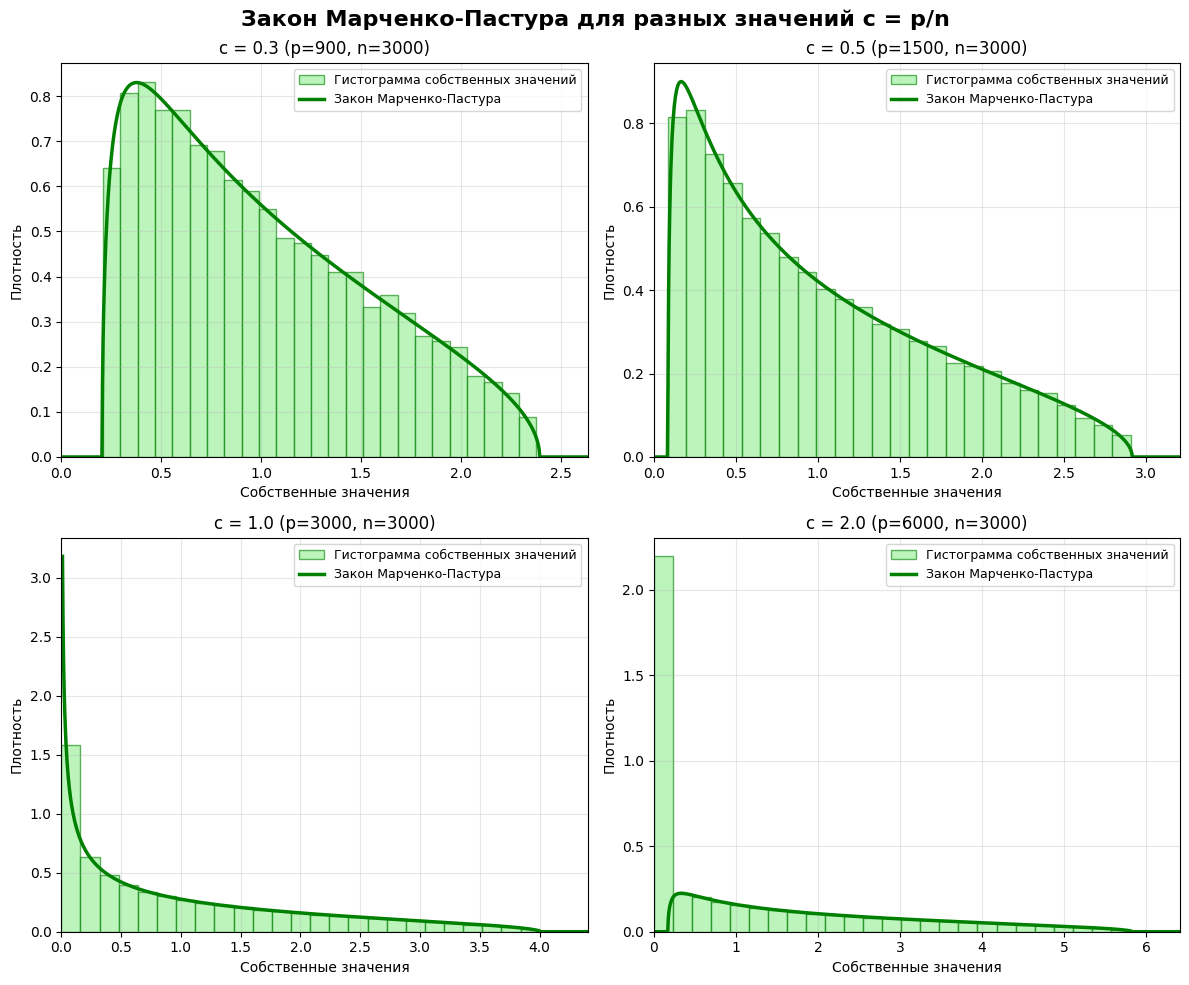

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Закон Марченко-Пастура для разных значений c = p/n', 
             fontsize=16, fontweight='bold')

for idx, c in enumerate(c_values):
    ax = axes[idx // 2, idx % 2]
    
    p = int(c * n)
    S = generate_covariance_matrix(p, n)
    eigenvalues, _ = eigh(S)
    
    # 1. Гистограмма собственных чисел
    ax.hist(eigenvalues, bins=num_bins, density=True, 
            alpha=0.6, color='lightgreen', edgecolor='green', 
            label='Гистограмма собственных значений')
    
    # 2. Теоретическая плотность Марченко-Пастура
    x_vals = np.linspace(0.01, max(eigenvalues) * 1.2, 1000)
    mp_curve = mp_pdf(x_vals, c)
    
    ax.plot(x_vals, mp_curve, 'g-', linewidth=2.5, 
            label='Закон Марченко-Пастура')
    
    ax.set_xlabel('Собственные значения', fontsize=10)
    ax.set_ylabel('Плотность', fontsize=10)
    ax.set_title(f'c = {c} (p={p}, n={n})', fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    theoretical_max = (1 + np.sqrt(c))**2 * 1.1
    ax.set_xlim([0, theoretical_max])
    ax.set_ylim(bottom=0)

plt.tight_layout()
#plt.savefig('./pictures for diplom/MP_law.png')
plt.show()